# **Projeto de Séries Temporais**

* Trabalho Individual - Matheus Lopes Lourenço
* 1666264@pucminas.edu.br

Nesse projeto usamos a base [Time Series Forecasts - Popular Benchmark Datasets](https://www.kaggle.com/datasets/giochelavaipiatti/time-series-forecasts-popular-benchmark-datasets). Por ter diversas bases nele iremos usar a base de Exchange Rate, a base contém taxas de câmbio diárias de oito países, cobrindo aproximadamente 1990 a 2016.

## **Descrição da Atividade postada no CANVAS**


1.   Acessar as API's demosntradas em sala ou https://www.kaggle.com/
2.   Selecionar a base de série temporal.
3.   Contextualizar o problema a ser resolvido.
4.   processamento de dados, detalhamento sobre existencia de quebras , outliers entre outros.
5. Analise de variáveis - análise descritiva, decomposição de componentes
6. Análise de aucorrelação
7. Validação de pressupostos, verificação de estacionaridade e normalidade.
8. Rodar o modelo , que melhor se ajusta.
9. Interpretação da saída (métricas de avaliação e coeficientes)






# 0. Glossário de Ajuda

| Termo                             | Explicação simples                                                                                               | No seu projeto                                                                               |
| --------------------------------- | ---------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------- |
| **Série temporal**                | Conjunto de observações registradas ao longo do tempo.                                                           | Taxa de câmbio USA observada diariamente.                                                    |
| **Data / Índice temporal**        | A data identifica a posição de cada observação no tempo.                                                         | A coluna `Date` foi convertida para data, ordenada e usada como índice.                      |
| **Taxa de câmbio**                | Relação de valor entre moedas.                                                                                   | É a variável analisada no projeto.                                                           |
| **Análise exploratória**          | Investigação inicial dos dados para entender seu comportamento.                                                  | Inclui estatísticas descritivas, gráficos, outliers e comportamento temporal.                |
| **Análise descritiva**            | Resumo estatístico dos dados.                                                                                    | Foram analisadas média, mediana, desvio-padrão, mínimo, máximo e quartis.                    |
| **Média**                         | Soma dos valores dividida pela quantidade de observações.                                                        | A média da série USA foi **0,776974**.                                                       |
| **Mediana**                       | Valor central dos dados ordenados.                                                                               | A mediana foi **0,761377**.                                                                  |
| **Desvio-padrão**                 | Mede a dispersão dos valores em torno da média.                                                                  | Foi aproximadamente **0,136620**.                                                            |
| **Quartil**                       | Divide os dados ordenados em partes.                                                                             | Q1 = 0,701422 e Q3 = 0,873477.                                                               |
| **IQR**                           | Intervalo interquartil: Q3 − Q1. É usado para identificar valores extremos.                                      | IQR ≈ **0,172055**.                                                                          |
| **Outlier**                       | Observação muito distante do comportamento central dos dados.                                                    | O método IQR não encontrou outliers na série USA.                                            |
| **Assimetria (Skewness)**         | Mede se a distribuição é mais concentrada para um dos lados.                                                     | A série apresentou assimetria positiva de aproximadamente **0,2611**.                        |
| **Curtose (Kurtosis)**            | Mede características relacionadas à concentração e às caudas da distribuição.                                    | A curtose foi aproximadamente **−0,3255**.                                                   |
| **Quebra estrutural**             | Mudança relevante no comportamento ou padrão da série ao longo do tempo.                                         | O projeto investiga mudanças comparando médias móveis e períodos diferentes.                 |
| **Média móvel**                   | Média calculada usando uma janela de observações consecutivas.                                                   | Foi utilizada uma janela de **30 períodos** para observar o comportamento da série.          |
| **Decomposição**                  | Separação da série em componentes para entender seu comportamento.                                               | Faz parte das etapas propostas no projeto.                                                   |
| **Tendência**                     | Movimento geral de crescimento ou queda da série ao longo do tempo.                                              | É um dos aspectos investigados na análise temporal.                                          |
| **Sazonalidade**                  | Padrão que se repete em determinados intervalos de tempo.                                                        | É um dos possíveis componentes analisados em séries temporais.                               |
| **Autocorrelação (ACF)**          | Mede a relação entre uma observação e valores anteriores da própria série.                                       | Utilizada para investigar dependência temporal.                                              |
| **Defasagem (Lag)**               | Distância temporal entre uma observação e uma observação anterior.                                               | Ex.: lag 1 compara o valor atual com o valor anterior.                                       |
| **PACF**                          | Autocorrelação parcial; mede a relação entre dois pontos considerando os efeitos das defasagens intermediárias.  | É utilizada para auxiliar na identificação da estrutura do modelo.                           |
| **Estacionaridade**               | Propriedade em que as características estatísticas da série permanecem relativamente estáveis ao longo do tempo. | É importante para a modelagem ARIMA e foi verificada no projeto.                             |
| **Diferenciação**                 | Subtração entre observações consecutivas para reduzir tendência e tornar a série mais estacionária.              | A série foi diferenciada antes de alguns modelos, fazendo `d = 0` na série já diferenciada.  |
| **ADF (Augmented Dickey-Fuller)** | Teste estatístico utilizado para verificar evidências de raiz unitária e avaliar estacionaridade.                | Faz parte das ferramentas utilizadas no notebook.                                            |
| **KPSS**                          | Teste estatístico usado para avaliar estacionaridade, com hipótese nula relacionada à estacionaridade.           | Também foi importado para a análise.                                                         |
| **ARIMA**                         | Modelo de previsão que combina autorregressão, diferenciação e média móvel.                                      | É a principal família de modelos utilizada no projeto.                                       |
| **AR**                            | Componente autorregressivo do ARIMA; usa valores anteriores da própria série.                                    | Aparece, por exemplo, no ARIMA(1,0,1).                                                       |
| **I (Integrated)**                | Componente relacionado à quantidade de diferenciações aplicadas à série.                                         | Representado pelo parâmetro `d`.                                                             |
| **MA**                            | Componente de média móvel baseado nos erros/resíduos anteriores.                                                 | Aparece, por exemplo, no ARIMA(0,0,1).                                                       |
| **ARIMA(p,d,q)**                  | Estrutura do modelo ARIMA. `p` = AR, `d` = diferenciação, `q` = MA.                                              | O projeto compara diferentes combinações desses parâmetros.                                  |
| **ARIMA(1,1,1)**                  | Modelo com 1 termo AR, 1 diferenciação e 1 termo MA.                                                             | É o modelo destacado na conclusão do projeto.                                                |
| **Resíduo**                       | Diferença entre o valor observado e o valor estimado pelo modelo.                                                | Os resíduos são analisados para verificar se o modelo deixou padrões não explicados.         |
| **Ruído branco**                  | Série de erros aproximadamente aleatórios, sem autocorrelação relevante.                                         | É o comportamento desejado para os resíduos.                                                 |
| **Ljung-Box**                     | Teste que verifica se existe autocorrelação nos resíduos.                                                        | No ARIMA(1,1,1), os p-valores foram 0,998392 e 0,999006 para lags 10 e 20.                   |
| **p-valor**                       | Indica a evidência contra a hipótese nula de um teste estatístico.                                               | No Ljung-Box, p > 0,05 levou à não rejeição da ausência de autocorrelação residual.          |
| **Jarque-Bera**                   | Teste que verifica se os dados/resíduos são compatíveis com uma distribuição normal.                             | O projeto conclui que os resíduos não apresentam normalidade.                                |
| **Normalidade**                   | Indica se os dados seguem aproximadamente uma distribuição normal.                                               | Foi avaliada como parte da validação dos pressupostos.                                       |
| **Heterocedasticidade**           | Quando a variância dos erros não permanece constante ao longo do tempo.                                          | O projeto identificou evidências de variância não constante nos resíduos.                    |
| **Homoscedasticidade**            | Situação oposta: variância dos erros aproximadamente constante.                                                  | É uma característica desejável em determinados diagnósticos estatísticos.                    |
| **AIC**                           | Critério de informação usado para comparar modelos, equilibrando ajuste e complexidade.                          | Aparece nos resultados dos modelos ARIMA.                                                    |
| **BIC**                           | Critério de informação semelhante ao AIC, mas penaliza mais fortemente modelos complexos.                        | Também aparece nos resultados dos modelos.                                                   |
| **Log Likelihood**                | Medida relacionada à qualidade de ajuste do modelo aos dados.                                                    | Aparece no resumo dos modelos ARIMA.                                                         |
| **Capacidade preditiva**          | Capacidade do modelo de produzir boas previsões para valores futuros.                                            | É um dos objetivos centrais do trabalho.                                                     |
| **MAE**                           | Erro absoluto médio entre previsão e valor observado.                                                            | Foi importado como métrica de avaliação.                                                     |
| **MSE**                           | Média dos erros ao quadrado. Penaliza erros maiores.                                                             | Foi utilizado/importado para avaliação dos modelos.                                          |
| **RMSE**                          | Raiz quadrada do MSE; expressa o erro na mesma unidade da variável prevista.                                     | Utilizado na avaliação da previsão.                                                          |
| **Coeficiente**                   | Parâmetro estimado pelo modelo que representa a contribuição de determinado componente.                          | Os coeficientes dos componentes AR/MA aparecem no `summary()` do ARIMA.                      |


#**1. Introdução**

As séries temporais são utilizadas para analisar fenômenos observados ao longo do tempo, permitindo identificar padrões, tendências, comportamentos sazonais e relações de dependência entre observações consecutivas.

Neste projeto foi utilizada a base Time Series Forecasts – Popular Benchmark Datasets, disponível no Kaggle. A base escolhida foi a de Exchange Rate, que contém taxas de câmbio diárias de oito países, abrangendo aproximadamente o período de 1990 a 2010.

Embora a base possua oito séries, neste trabalho será analisada especificamente a série denominada USA.

O objetivo é avaliar o comportamento temporal da série, verificar suas propriedades estatísticas e construir um modelo de previsão capaz de estimar valores futuros.

#**2. Contextualização do problema**

A taxa de câmbio é uma variável econômica que apresenta comportamento dinâmico e pode sofrer alterações ao longo do tempo em função de diferentes condições econômicas e financeiras.

Nesse contexto, surge a seguinte questão:

É possível utilizar um modelo de séries temporais para representar adequadamente o comportamento histórico da série de taxa de câmbio USA e realizar previsões de seus valores futuros?

Para responder a essa questão serão realizadas as seguintes etapas:

tratamento e organização dos dados;
análise exploratória;
identificação de possíveis outliers;
investigação de possíveis quebras estruturais;
decomposição da série;
análise de autocorrelação;
verificação da estacionaridade;
avaliação da normalidade;
estimação de diferentes modelos ARIMA;
comparação dos modelos;
diagnóstico dos resíduos;
avaliação da capacidade preditiva.

# **3. Importação das bibliotecas e carregamento dos dados**

In [344]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

df = pd.read_csv("exchange_rate.csv")

df.rename(
    columns={
        "date": "Date",
        "1": "USA",
        "2": "Australia",
        "3": "UK",
        "4": "Canada",
        "5": "Suiça",
        "6": "China",
        "7": "Japão",
        "8": "Brasil"
    },
    inplace=True
)

df.head()

,Date,USA,Australia,UK,Canada,Suiça,China,Japão,Brasil
0,1990/1/1,0.7855,1.6110,0.861698,0.634196,0.211242,0.006838,0.5930,0.525486
1,1990/1/2,0.7818,1.6100,0.861104,0.633513,0.211242,0.006863,0.5940,0.523972
2,1990/1/3,0.7867,1.6293,0.861030,0.648508,0.211242,0.006975,0.5973,0.526316
3,1990/1/4,0.7860,1.6370,0.862069,0.650618,0.211242,0.006953,0.5970,0.523834
4,1990/1/5,0.7849,1.6530,0.861995,0.656254,0.211242,0.006940,0.5985,0.527426


#**4. Tratamento e preparação dos dados**

Inicialmente, a variável Date foi convertida para o formato de data. Em seguida, os registros foram ordenados cronologicamente e a data foi definida como índice da série temporal.

In [345]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.set_index("Date", inplace=True)
df.head()

,USA,Australia,UK,Canada,Suiça,China,Japão,Brasil
Date,,,,,,,,
1990-01-01,0.7855,1.6110,0.861698,0.634196,0.211242,0.006838,0.5930,0.525486
1990-01-02,0.7818,1.6100,0.861104,0.633513,0.211242,0.006863,0.5940,0.523972
1990-01-03,0.7867,1.6293,0.861030,0.648508,0.211242,0.006975,0.5973,0.526316
1990-01-04,0.7860,1.6370,0.862069,0.650618,0.211242,0.006953,0.5970,0.523834
1990-01-05,0.7849,1.6530,0.861995,0.656254,0.211242,0.006940,0.5985,0.527426


### **4.1 Verificação de Valores da Dataframe**

In [346]:
df.shape

(7588, 8)

In [347]:
df.isna().sum()

,0
USA,0
Australia,0
UK,0
Canada,0
Suiça,0
China,0
Japão,0
Brasil,0


In [348]:
df.index.duplicated().sum()

np.int64(0)

# **5. Seleção da série de interesse**

In [349]:
serie = df["USA"].copy()

#**6. Análise Descritiva**

A assimetria positiva, embora relativamente pequena, indica uma leve assimetria à direita na distribuição dos valores. A curtose negativa indica uma distribuição menos concentrada nas caudas quando comparada a uma distribuição normal.

A média foi de 0,776974, enquanto a mediana foi de 0,761377, indicando certa proximidade entre essas duas medidas de tendência central.

In [350]:
serie.describe()

,USA
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [351]:
df["USA"].skew() #assimetria

np.float64(0.2611267376737365)

In [352]:
df["USA"].kurt() #curtose

np.float64(-0.3255393714603634)

#**7. Outliers**

A análise dos outliers será realizada considerando os limites definidos pelo método IQR. Os valores identificados como extremos não serão automaticamente removidos, pois, em uma série financeira/econômica, valores extremos podem representar mudanças reais do mercado e não necessariamente erros de coleta.

Caso os valores identificados sejam mantidos, essa decisão deverá ser justificada pelo fato de que a remoção indiscriminada poderia eliminar informações relevantes da dinâmica temporal.

In [353]:
Q1 = serie.quantile(0.25)
Q3 = serie.quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = serie[
    (serie < limite_inferior) | (serie > limite_superior)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)
print("Quantidade de outliers:", len(outliers))

Q1: 0.701422
Q3: 0.873477
IQR: 0.17205499999999996
Limite inferior: 0.44333950000000005
Limite superior: 1.1315594999999998
Quantidade de outliers: 0


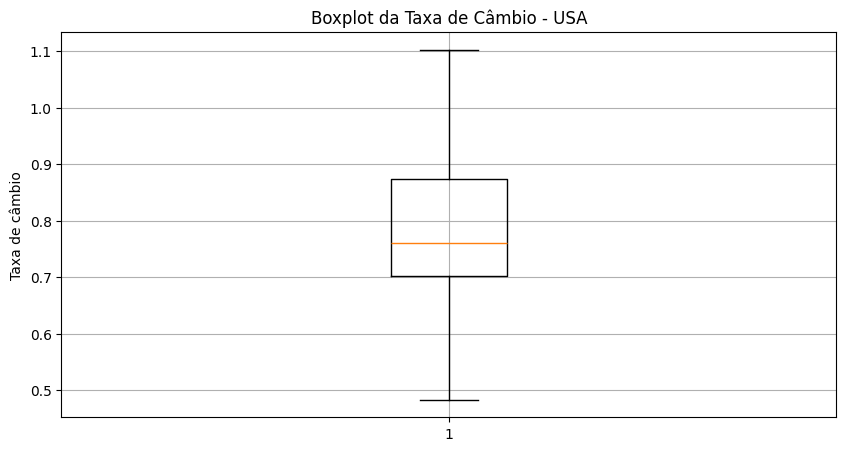

In [354]:
plt.figure(figsize=(10, 5))
plt.boxplot(serie)
plt.title("Boxplot da Taxa de Câmbio - USA")
plt.ylabel("Taxa de câmbio")
plt.grid(True)
plt.show()

#**8. Quebras Estruturais**
Comportamento da série ao longo do período.

Uma forma inicial de investigação consiste em comparar médias móveis e estatísticas entre diferentes períodos.

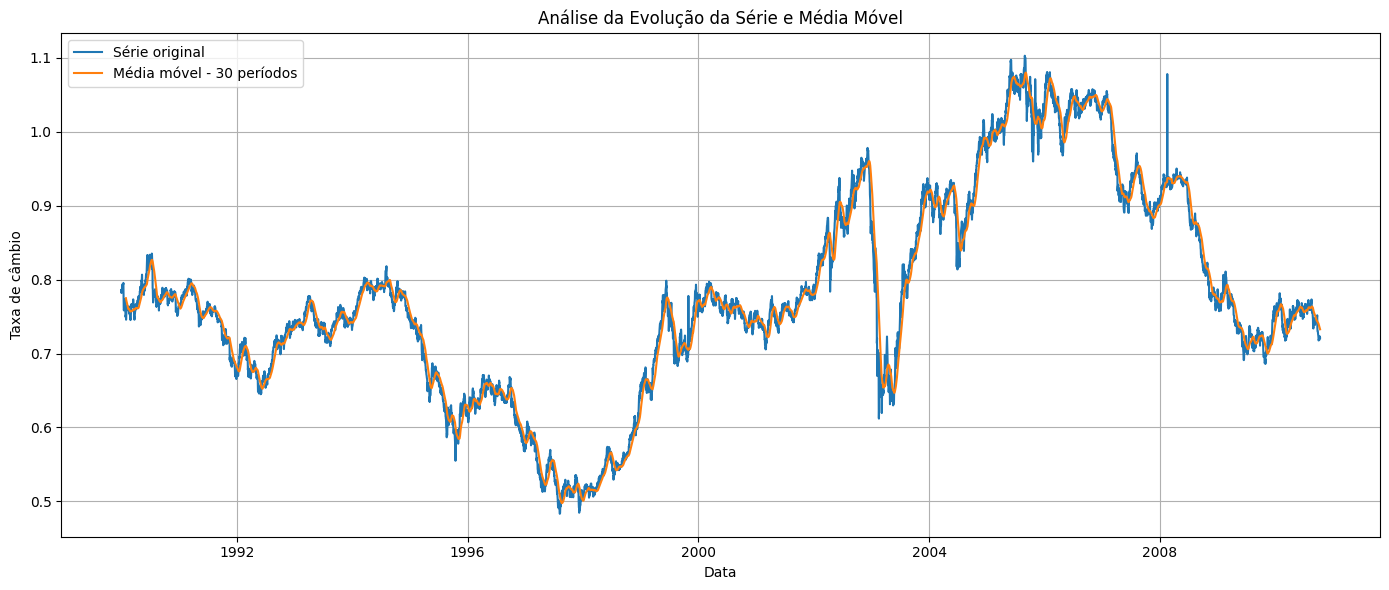

In [355]:
media_movel = serie.rolling(window=30).mean()
desvio_movel = serie.rolling(window=30).std()

plt.figure(figsize=(14, 6))
plt.plot(serie, label="Série original")
plt.plot(media_movel, label="Média móvel - 30 períodos")
plt.title("Análise da Evolução da Série e Média Móvel")
plt.xlabel("Data")
plt.ylabel("Taxa de câmbio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [356]:
n_blocos = 4

blocos = np.array_split(serie, n_blocos)

for i, bloco in enumerate(blocos, 1):
  print(
      f"Bloco {i}: "
      f"Média = {bloco.mean():.6f} | " f"Desvio-padrão = {bloco.std():.6f}"
  )

Bloco 1: Média = 0.749087 | Desvio-padrão = 0.038004
Bloco 2: Média = 0.626634 | Desvio-padrão = 0.082798
Bloco 3: Média = 0.845332 | Desvio-padrão = 0.104805
Bloco 4: Média = 0.886842 | Desvio-padrão = 0.123537


/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


# **9. Visualização da série temporal**

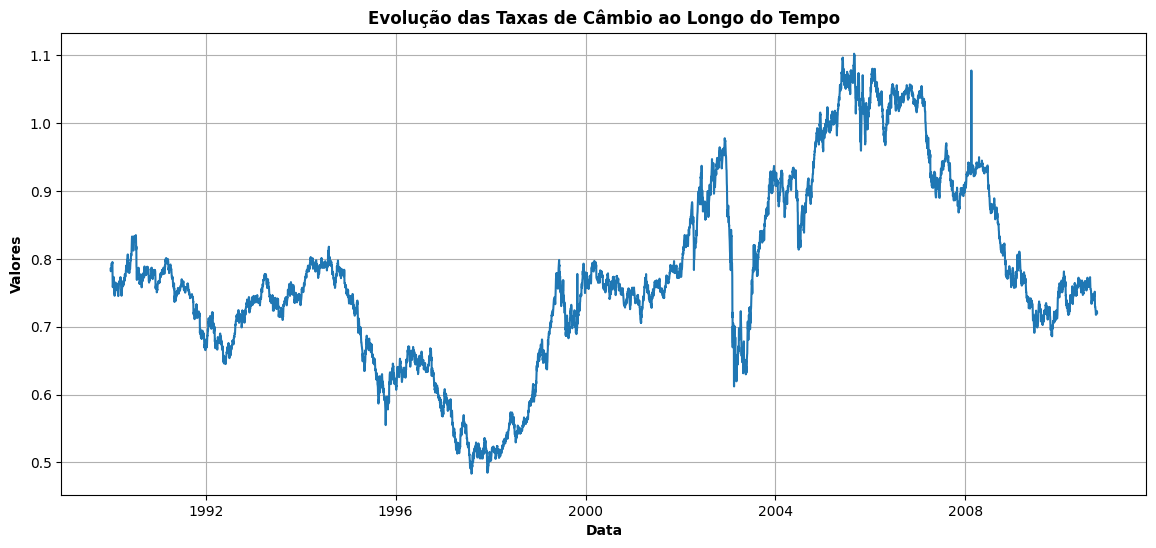

In [357]:
plt.figure(figsize=(14, 6))
plt.plot(serie)
plt.title("Evolução das Taxas de Câmbio ao Longo do Tempo", fontweight='bold')
plt.xlabel("Data", fontweight='bold')
plt.ylabel("Valores", fontweight='bold')
plt.grid(True)
plt.show()

# **10. Decomposição das Variáveis**

A decomposição permite separar a série em componentes de:

* Tendência;
* Sazonalidade;
* Resíduos.

Como a base possui observações diárias, será considerada inicialmente uma periodicidade de 7 observações, representando um possível padrão semanal.

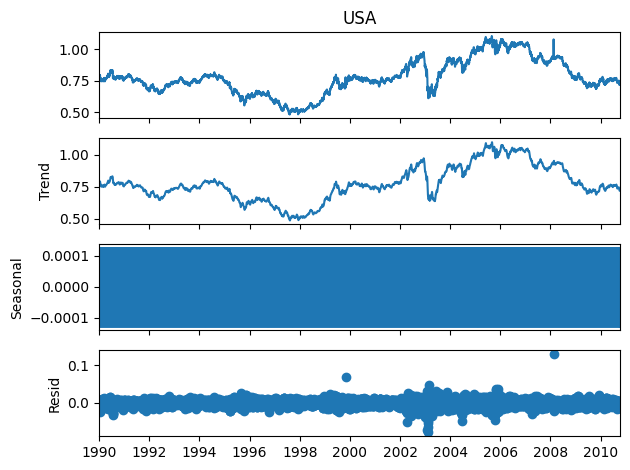

In [358]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
decomposicao = seasonal_decompose(
    df["USA"],
    model="additive",
    period=7,
    two_sided=False
)

decomposicao.plot()
plt.show()

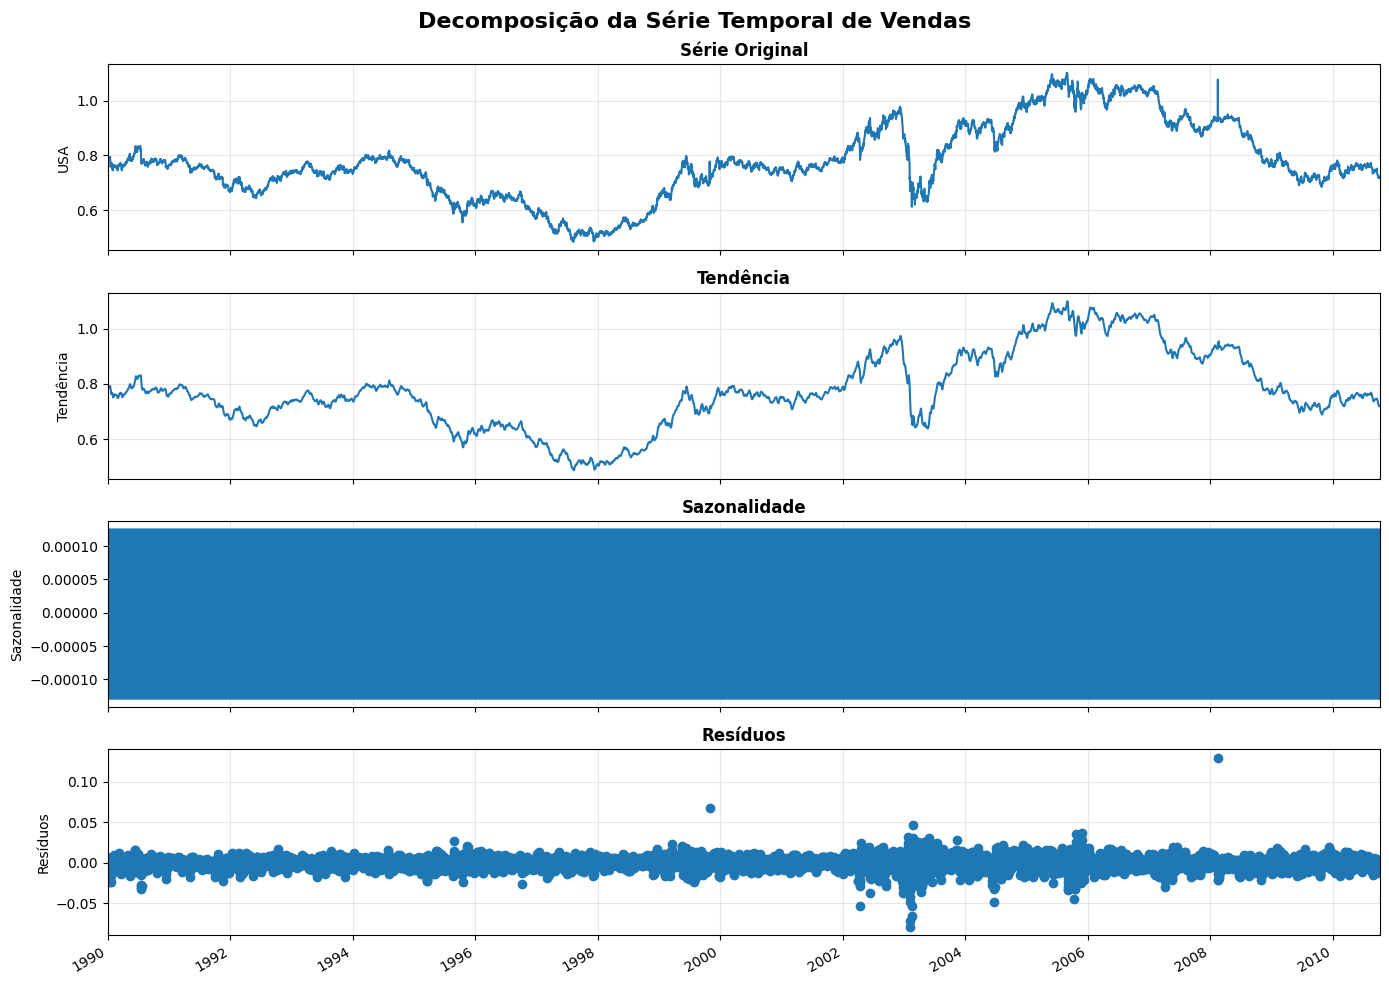

In [359]:
# Decomposição da série temporal
decomposicao = seasonal_decompose(
    df["USA"],
    model="additive",
    period=7,
    two_sided=False
)

# Criando a figura com tamanho maior
fig = decomposicao.plot()

# Ajustando o tamanho da figura
fig.set_size_inches(14, 10)
fig.suptitle(
    "Decomposição da Série Temporal de Vendas",
    fontsize=16,
    fontweight="bold"
)

titulos = ["Série Original", "Tendência", "Sazonalidade", "Resíduos"]
rotulos = ["USA", "Tendência", "Sazonalidade", "Resíduos"]

for ax, titulo, rotulo in zip(fig.axes, titulos, rotulos):
    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.set_ylabel(rotulo)
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()

A decomposição permite avaliar separadamente o comportamento da tendência, da sazonalidade e dos resíduos.

A escolha de period=7 foi utilizada para investigar uma possível periodicidade semanal. Entretanto, a existência de sazonalidade significativa deve ser avaliada visualmente e por meio das demais análises da série, não sendo possível concluir apenas pela definição do parâmetro.

# **11. Análise de Autocorrelação**
A autocorrelação permite verificar a relação entre uma observação e seus valores anteriores.

## **11.1 ACF (Autocorrelation Function)**
Mostra a correlação da série com seus próprios valores anteriores (lags).

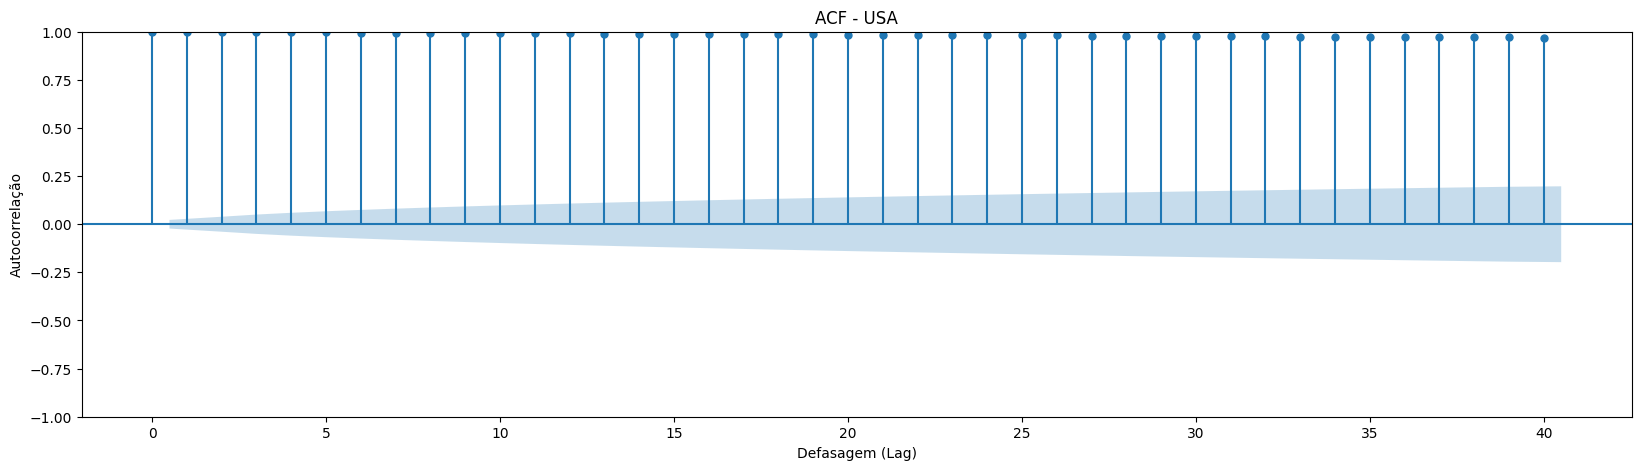

In [360]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

serie = df["USA"].dropna()

plt.figure(figsize=(20, 5))
plot_acf(serie, lags=40, ax=plt.gca())

plt.title("ACF - USA")
plt.xlabel("Defasagem (Lag)")
plt.ylabel("Autocorrelação")
plt.show()

## **11.2 PACF (Partial Autocorrelation Function)**
Mostra a correlação entre a série e seus valores anteriores, eliminando o efeito dos lags intermediários.

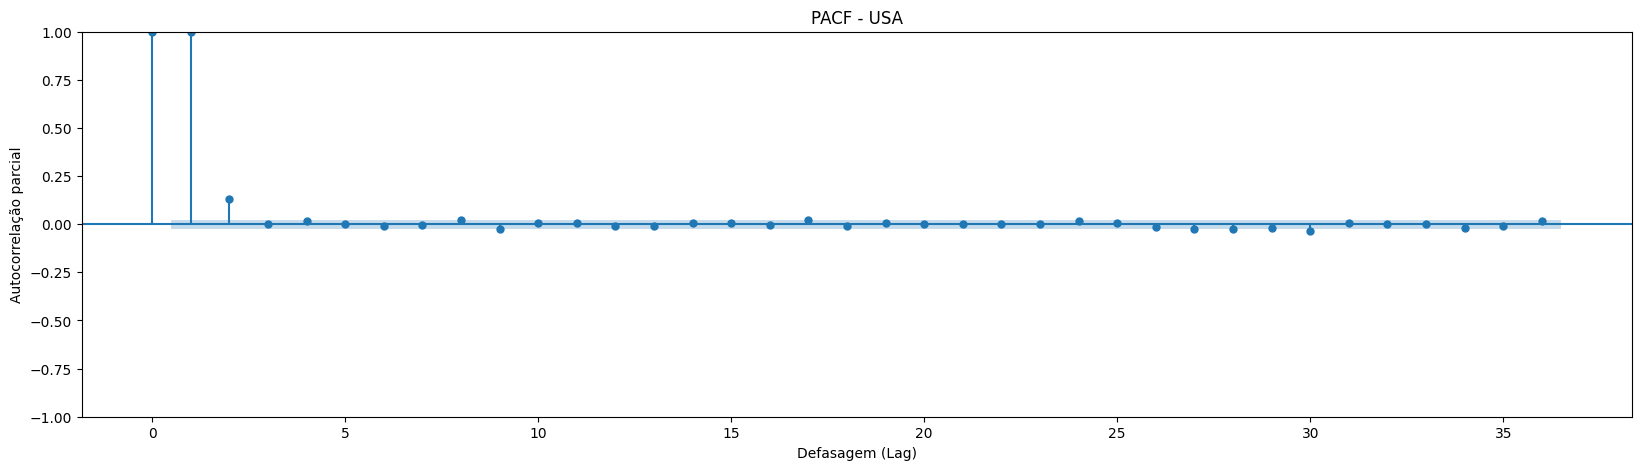

In [361]:
serie = df["USA"].dropna()

plt.figure(figsize=(20, 5))
plot_pacf(serie, lags=36, ax=plt.gca(), method="ywm")

plt.title("PACF - USA")
plt.xlabel("Defasagem (Lag)")
plt.ylabel("Autocorrelação parcial")
plt.show()

## **11.3 Conclusão da Análise**
A análise da função de autocorrelação (ACF) revelou valores elevados de **autocorrelação em diversos períodos**, indicando **forte persistência temporal e sugerindo que a série original não apresenta estacionariedade**.

Na função de autocorrelação parcial (PACF), observou-se uma **forte correlação no primeiro lag**, seguida por uma **redução significativa nos demais períodos**. Esse comportamento sugere a **possível presença de um componente autorregressivo** de primeira ordem.

#**12. Verificação de Estacionaridade**

A estacionaridade é uma propriedade importante para a modelagem ARIMA.

##**12.1 ADF**

In [362]:
# Teste de ADF
from statsmodels.tsa.stattools import adfuller

resultado_adf = adfuller(df["USA"].dropna())

print("Teste ADF")
print("Estatística:", resultado_adf[0])
print("P-valor:", resultado_adf[1])

if resultado_adf[1] < 0.05:
    print("Resultado: A série é ESTACIONÁRIA.")
else:
    print("Resultado: A série NÃO é ESTACIONÁRIA.")

Teste ADF
Estatística: -1.6649941807382342
P-valor: 0.4492327353597477
Resultado: A série NÃO é ESTACIONÁRIA.


/tmp/ipykernel_3099/2939253457.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_adf = adfuller(df["USA"].dropna())


##**12.2 KPSS**

In [363]:
# Teste de KPSS
resultado_kpss = kpss(
    df["USA"].dropna(),
    regression="c",
    nlags="auto"
)

print("\nTeste KPSS")
print("Estatística:", resultado_kpss[0])
print("P-valor:", resultado_kpss[1])

if resultado_kpss[1] < 0.05:
    print("Resultado: A série NÃO é estacionária.\n")
else:
    print("Resultado: A série é ESTACIONÁRIA.\n")


Teste KPSS
Estatística: 5.291660252110324
P-valor: 0.01
Resultado: A série NÃO é estacionária.



/tmp/ipykernel_3099/409269920.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  resultado_kpss = kpss(
/tmp/ipykernel_3099/409269920.py:2: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_kpss = kpss(


# **13. Aplicando a 1ª Diferença**

In [364]:
serie_diff = df["USA"].diff().dropna()
print(serie_diff.head())

Date
1990-01-02   -0.0037
1990-01-03    0.0049
1990-01-04   -0.0007
1990-01-05   -0.0011
1990-01-06    0.0017
Name: USA, dtype: float64


In [365]:
resultado_adf_diff = adfuller(serie_diff)

if resultado_adf_diff[1] < 0.05:
    print("A série está estacionária!\n")
    serie_estacionaria = serie_diff
    numero_diferencas = 1

else:
    print("A série NÃO está estacionária após a primeira diferenciação!\n")
    serie_diff2 = serie_diff.diff().dropna()
    resultado_adf_diff2 = adfuller(serie_diff2)
    print("Aplicando segunda diferenciação...")

    if resultado_adf_diff2[1] < 0.05:
        print("A série está estacionária!")
        serie_estacionaria = serie_diff2
        numero_diferencas = 2
    else:
        print("A série ainda NÃO está estacionária!")
        serie_estacionaria = serie_diff2
        numero_diferencas = 2

print("\nNúmero de diferenciações:", numero_diferencas)
print("P-valor ADF:", adfuller(serie_estacionaria)[1])

/tmp/ipykernel_3099/3749441962.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_adf_diff = adfuller(serie_diff)


A série está estacionária!


Número de diferenciações: 1
P-valor ADF: 0.0


/tmp/ipykernel_3099/3749441962.py:24: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  print("P-valor ADF:", adfuller(serie_estacionaria)[1])


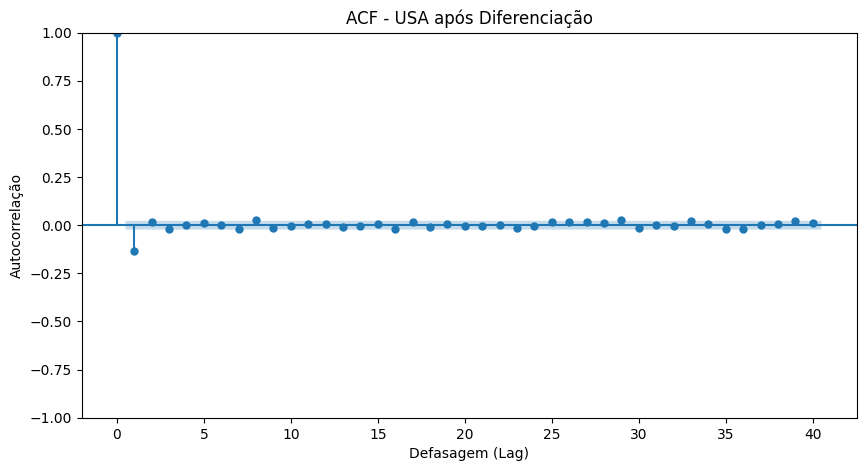

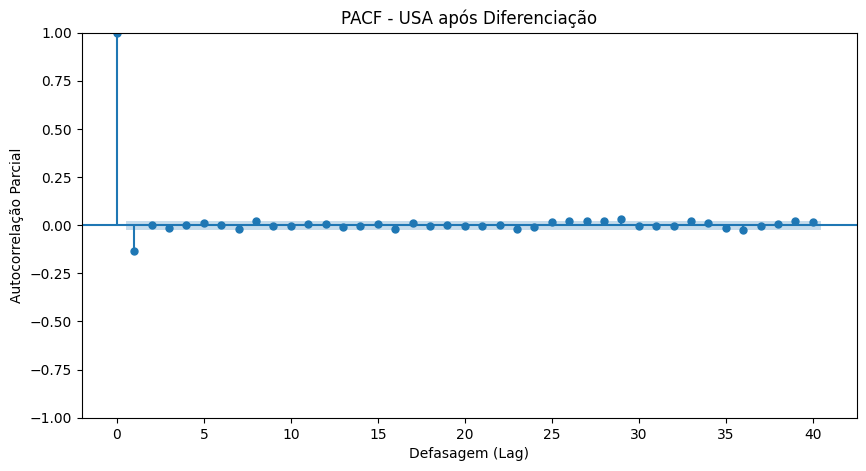

In [366]:
# ACF
plt.figure(figsize=(10, 5))
plot_acf(serie_estacionaria, lags=40, ax=plt.gca())
plt.title("ACF - USA após Diferenciação")
plt.xlabel("Defasagem (Lag)")
plt.ylabel("Autocorrelação")
plt.show()

# PACF
plt.figure(figsize=(10, 5))
plot_pacf(serie_estacionaria, lags=40, ax=plt.gca(), method="ywm")
plt.title("PACF - USA após Diferenciação")
plt.xlabel("Defasagem (Lag)")
plt.ylabel("Autocorrelação Parcial")
plt.show()

# **14. Análise de Normalidade**
A normalidade da série original também foi investigada por meio do teste de Jarque-Bera.

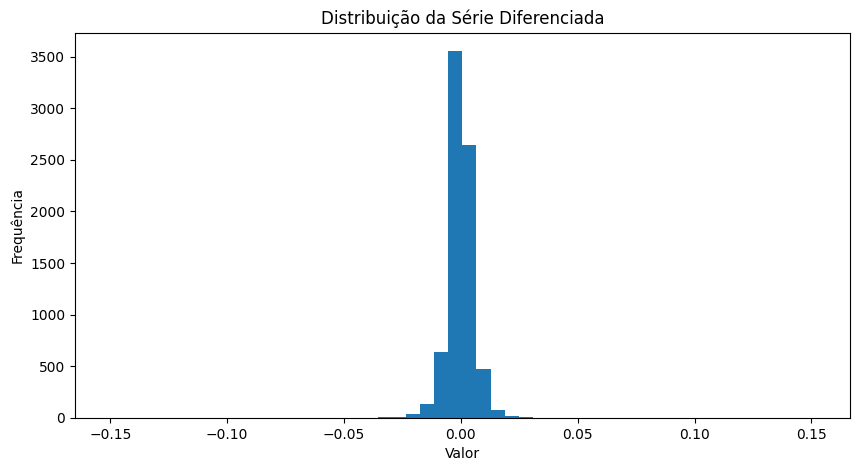

In [367]:
plt.figure(figsize=(10,5))
plt.hist(serie_estacionaria, bins=50)
plt.title("Distribuição da Série Diferenciada")
plt.xlabel("Valor")
plt.ylabel("Frequência")
plt.show()

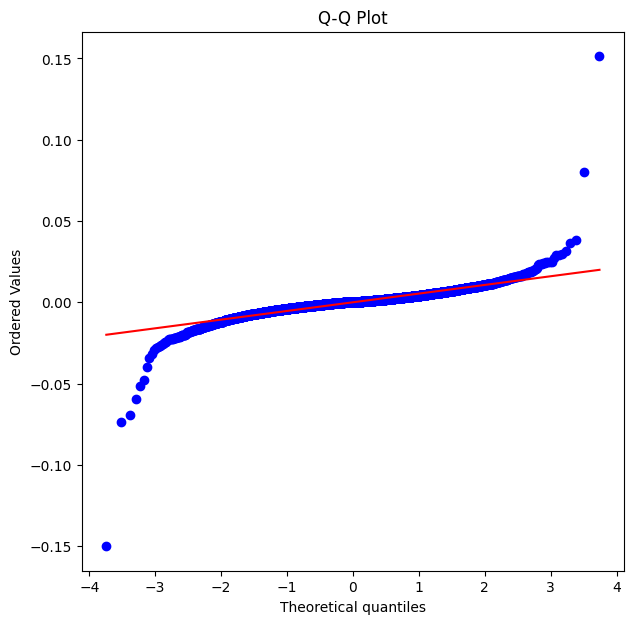

In [368]:
from scipy import stats

plt.figure(figsize=(7,7))
stats.probplot(serie_estacionaria, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [369]:
from scipy.stats import jarque_bera

jb_stat, p_value = jarque_bera(serie_estacionaria)

print("Estatística Jarque-Bera:", jb_stat)
print("P-valor:", p_value)

if p_value < 0.05:
    conclusao = "Rejeita-se H0. A série não apresenta distribuição normal."
else:
    conclusao = "Não se rejeita H0. Não há evidências suficientes contra a normalidade."

print(conclusao)

Estatística Jarque-Bera: 4161024.7642631587
P-valor: 0.0
Rejeita-se H0. A série não apresenta distribuição normal.


##**14.1 Normalização dos Dados**
Mesmo aplicando a normalização os resultados, não foram suficientes para que tornasem os dados em uma distribuição normal. Foi aplicado o pacote de pre-processamento dos dados para isso. Todavia, mesmo aplicando o teste de Jarque Bera não foi o suficiente para "reajustar". O que demosntra evidência forte de que os resíduos não são **normalmente distribuídos e apresentam heterocedasticidade**

Isso pode acontecer porque normalizar os dados não significa necessariamente torná-los “normais” (com distribuição normal). A normalização apenas altera a escala dos valores, enquanto a distribuição estatística continua podendo ser assimétrica ou apresentar outliers. Portanto, mesmo após a normalização, os dados podem não seguir uma distribuição normal — e isso não significa que o procedimento tenha sido feito incorretamente.

In [370]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df["USA_Normalizado"] = scaler.fit_transform(
    df[["USA"]]
)

print("Média:", df["USA_Normalizado"].mean())
print("Desvio padrão:", df["USA_Normalizado"].std())
scaler = StandardScaler()

Média: 1.0787364675746382e-15
Desvio padrão: 1.0000659000297258


In [371]:
jb_stat, p_value = jarque_bera(df["USA_Normalizado"])

print("Estatística Jarque-Bera:", jb_stat)
print("P-valor:", p_value)

if p_value < 0.05:
    conclusao = "Rejeita-se H0. A série não apresenta distribuição normal."
else:
    conclusao = "Não se rejeita H0. Não há evidências suficientes contra a normalidade."

print(conclusao)

Estatística Jarque-Bera: 119.82469905362805
P-valor: 9.558664149895817e-27
Rejeita-se H0. A série não apresenta distribuição normal.


# **15. Aplicando Modelos de Previsão**

##**AR — AutoRegressive**
Modelo usa valores passados da própria série para prever o próximo valor.

In [372]:
from statsmodels.tsa.ar_model import AutoReg

modelo_ar = AutoReg(
    serie_estacionaria,
    lags=1,
    trend='c'
).fit()

print(modelo_ar.summary(),'\n')

                            AutoReg Model Results                             
Dep. Variable:                    USA   No. Observations:                 7586
Model:                     AutoReg(1)   Log Likelihood               28050.166
Method:               Conditional MLE   S.D. of innovations              0.006
Date:                Thu, 10 Sep 2026   AIC                         -56094.333
Time:                        00:28:18   BIC                         -56073.531
Sample:                    01-03-1990   HQIC                        -56087.194
                         - 10-10-2010                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -9.158e-06   6.88e-05     -0.133      0.894      -0.000       0.000
USA.L1        -0.1314      0.011    -11.545      0.000      -0.154      -0.109
                                    Roots           

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


##**MA — Moving Average**
Utiliza os erros de previsão passados

In [373]:
'''
p = 1 → componente AR
d = 0 → porque já diferenciamos a série
q = 1 → componente MA
'''

from statsmodels.tsa.arima.model import ARIMA
modelo_ma = ARIMA(
    serie_estacionaria,
    order=(0, 0, 1)
).fit()

print('\n',modelo_ma.summary(),'\n')

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



                                SARIMAX Results                                
Dep. Variable:                    USA   No. Observations:                 7587
Model:                 ARIMA(0, 0, 1)   Log Likelihood               28053.387
Date:                Thu, 10 Sep 2026   AIC                         -56100.773
Time:                        00:28:21   BIC                         -56079.970
Sample:                    01-02-1990   HQIC                        -56093.634
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -9.476e-06   6.25e-05     -0.152      0.880      -0.000       0.000
ma.L1         -0.1314      0.002    -61.260      0.000      -0.136      -0.127
sigma2      3.596e-05   1.01e-07    356.221      0

##**ARMA**

In [374]:
modelo_arma = ARIMA(
    serie_estacionaria,
    order=(1, 0, 1)
).fit()

print('\n',modelo_arma.summary(),'\n')

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



                                SARIMAX Results                                
Dep. Variable:                    USA   No. Observations:                 7587
Model:                 ARIMA(1, 0, 1)   Log Likelihood               28054.170
Date:                Thu, 10 Sep 2026   AIC                         -56100.341
Time:                        00:28:25   BIC                         -56072.604
Sample:                    01-02-1990   HQIC                        -56090.822
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -9.334e-06   6.38e-05     -0.146      0.884      -0.000       0.000
ar.L1         -0.1268      0.045     -2.790      0.005      -0.216      -0.038
ma.L1         -0.0046      0.046     -0.101      0

##**ARIMA**

In [375]:
modelo_arima = ARIMA(
    df["USA"].dropna(),
    order=(1, 1, 0)
).fit()

print(modelo_arima.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                    USA   No. Observations:                 7588
Model:                 ARIMA(1, 1, 0)   Log Likelihood               28054.159
Date:                Thu, 10 Sep 2026   AIC                         -56104.319
Time:                        00:28:25   BIC                         -56090.450
Sample:                    01-01-1990   HQIC                        -56099.559
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1314      0.002    -64.439      0.000      -0.135      -0.127
sigma2      3.595e-05   9.94e-08    361.720      0.000    3.58e-05    3.61e-05
Ljung-Box (L1) (Q):                   0.00   Jarque-

##**SARIMA**
Extensão do ARIMA para séries que apresentam sazonalidade.

##**Holt-Winters / Exponential Smoothing**
* tendência
* sazonalidade
* comportamento relativamente regular

In [376]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

modelo_hw = ExponentialSmoothing(
    df["USA"],
    trend="add",
    seasonal=None
).fit()

print('\n',modelo_hw.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



                        ExponentialSmoothing Model Results                       
Dep. Variable:                      USA   No. Observations:                 7588
Model:             ExponentialSmoothing   SSE                              0.273
Optimized:                         True   AIC                         -77641.010
Trend:                         Additive   BIC                         -77613.272
Seasonal:                          None   AICC                        -77640.999
Seasonal Periods:                  None   Date:                 Thu, 10 Sep 2026
Box-Cox:                          False   Time:                         00:28:26
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.8698403                alpha                 True
smoothing_trend             0.00

#**16. Separação em Treino e Teste**

In [377]:
# Separação 80% treino / 20% teste
tamanho_teste = int(len(serie) * 0.2)
treino = serie.iloc[:-tamanho_teste]
teste = serie.iloc[-tamanho_teste:]

print("Total de observações:", len(serie))
print("Treino:", len(treino))
print("Teste:", len(teste))

Total de observações: 7588
Treino: 6071
Teste: 1517


#**17. Estimando Modelos ARIMA**

In [378]:
from statsmodels.tsa.arima.model import ARIMA

modelo_110 = ARIMA(
    treino,
    order=(1, 1, 0)
)

#resultado_110 = modelo_110.fit()
#print(resultado_110.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [379]:
modelo_011 = ARIMA(
    treino,
    order=(0, 1, 1)
)

#resultado_011 = modelo_011.fit()
#print(resultado_011.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [380]:
modelo_111 = ARIMA(
    treino,
    order=(1, 1, 1)
)

#resultado_111 = modelo_111.fit()
#print(resultado_111.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [381]:
modelo_210 = ARIMA(
    treino,
    order=(2, 1, 0)
)

#resultado_210 = modelo_210.fit()
#print(resultado_210.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [382]:
modelo_110 = ARIMA(treino, order=(1,1,0)).fit()
modelo_011 = ARIMA(treino, order=(0,1,1)).fit()
modelo_111 = ARIMA(treino, order=(1,1,1)).fit()
modelo_210 = ARIMA(treino, order=(2,1,0)).fit()

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

In [383]:
comparacao = pd.DataFrame({
    "Modelo": [
        "ARIMA(1,1,0)",
        "ARIMA(0,1,1)",
        "ARIMA(1,1,1)",
        "ARIMA(2,1,0)"
    ],
    "AIC": [
        round(modelo_110.aic, 2),
        round(modelo_011.aic, 2),
        round(modelo_111.aic, 2),
        round(modelo_210.aic, 2)
    ],
    "BIC": [
        round(modelo_110.bic, 2),
        round(modelo_011.bic, 2),
        round(modelo_111.bic, 2),
        round(modelo_210.bic, 2)
    ]
})

comparacao.sort_values("AIC")

,Modelo,AIC,BIC
2,"ARIMA(1,1,1)",-45440.50,-45420.36
3,"ARIMA(2,1,0)",-45436.04,-45415.90
0,"ARIMA(1,1,0)",-45434.34,-45420.92
1,"ARIMA(0,1,1)",-45433.33,-45419.90


##**17.0 Teste de Auto ARIMA**

In [384]:
modelo_auto = auto_arima(
    treino,
    seasonal=False,
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action="ignore"
)

print(modelo_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-45435.136, Time=4.07 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-45412.927, Time=0.92 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-45432.668, Time=0.63 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-45431.649, Time=1.75 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-45414.639, Time=0.31 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-45436.869, Time=8.27 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-45433.109, Time=3.92 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-45438.814, Time=11.17 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-45406.927, Time=3.66 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-45434.347, Time=1.55 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-45440.496, Time=1.71 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-45433.326, Time=0.65 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-45434.343, Time=0.72 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-45408.642, Time=1.61 sec
 ARI

In [385]:
previsao_auto = modelo_auto.predict(
    n_periods=len(teste)
)

previsao = resultado.forecast(
    steps=len(teste)
)

In [386]:
mae_auto = mean_absolute_error(
    teste,
    previsao_auto
)

rmse_auto = np.sqrt(
    mean_squared_error(
        teste,
        previsao_auto
    )
)

print("Auto ARIMA")
print("MAE :", round(mae_auto, 4))
print("RMSE:", round(rmse_auto, 4))

Auto ARIMA
MAE : 0.179
RMSE: 0.2069


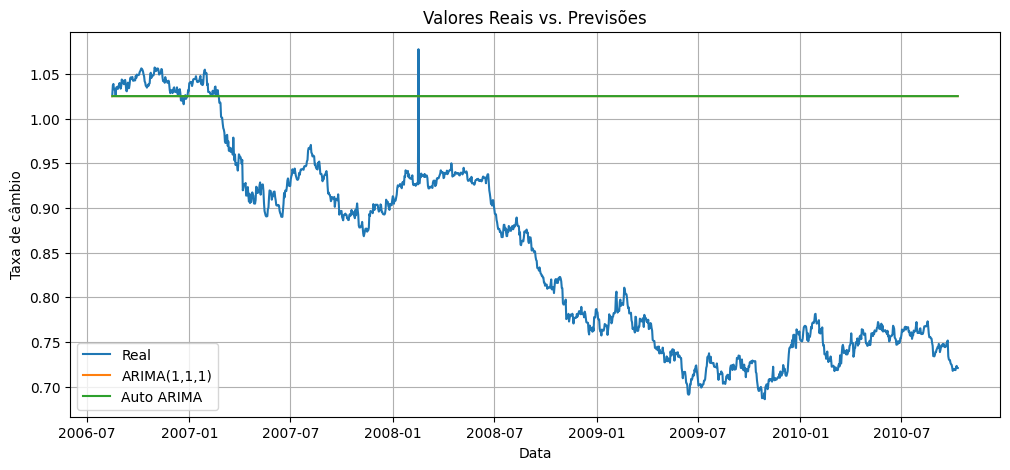

In [387]:
plt.figure(figsize=(12, 5))

plt.plot(teste.index, teste, label="Real")
plt.plot(teste.index, previsao, label="ARIMA(1,1,1)")
plt.plot(teste.index, previsao_auto, label="Auto ARIMA")

plt.title("Valores Reais vs. Previsões")
plt.xlabel("Data")
plt.ylabel("Taxa de câmbio")
plt.legend()
plt.grid(True)

plt.show()

**OBS** Quanto menor o AIC e o BIC, melhor o modelo em termos de ajuste penalizado pela complexidade.

## **17.1 Conclusão**
Foram comparados os modelos ARIMA(1,1,0), ARIMA(0,1,1), ARIMA(1,1,1) e ARIMA(2,1,0), utilizando **os critérios AIC e BIC, nos quais menores valores indicam melhor ajuste. O ARIMA(1,1,1) apresentou o menor AIC, com -45440,50, enquanto o ARIMA(2,1,0) apresentou o menor BIC, com -45415,90. Apesar dessas diferenças, os valores dos critérios foram relativamente próximos entre os modelos**.

Com base nesses resultados, o ARIMA(1,1,1) foi **selecionado inicialmente como modelo final por apresentar o menor valor de AIC**. Entretanto, a escolha do modelo não deve considerar apenas os critérios de informação, sendo necessário avaliar **também o comportamento dos resíduos e o desempenho das previsões fora da amostra**.

Dessa forma, o **diagnóstico dos resíduos e a avaliação do desempenho preditivo são importantes para confirmar se o modelo escolhido realmente apresenta capacidade de previsão**. No caso do ARIMA(1,1,1), os **resultados mostraram desempenho muito próximo ao modelo baseline, indicando que, embora o modelo tenha apresentado um ajuste adequado segundo o AIC, o ganho preditivo foi pequeno**.



# **18.Modelo de previssão dos Resultados**

In [388]:
resultado = modelo_111

In [389]:
previsao = resultado.forecast(
    steps=len(teste)
)

##**18.1 Avaliação da Previsão**

Para verificar se o modelo ARIMA **apresentou ganho preditivo em relação a uma abordagem simples, foi utilizado como baseline o último valor observado no conjunto de treinamento**. A comparação entre MAE e RMSE permite verificar se o **ARIMA efetivamente reduz os erros de previsão em relação a uma estratégia ingênua**.

In [390]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
# Erro Absoluto Médio - Quanto a previsão ficou distante do valor real - "Em média, quanto eu erro?"
mae = mean_absolute_error(
    teste,
    previsao
)
# Raiz do Erro Quadrático Médio - mede o erro de previsão - "Quanto eu erro, dando uma punição maior para erros muito grandes?"
rmse = np.sqrt(
    mean_squared_error(
        teste,
        previsao
    )
)

print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))

MAE : 0.179
RMSE: 0.2069


In [391]:
previsao_naive = np.repeat(treino.iloc[-1], len(teste))

# MAE
mae_naive = mean_absolute_error(
    teste,
    previsao_naive
)

# RMSE
rmse_naive = np.sqrt(
    mean_squared_error(
        teste,
        previsao_naive
    )
)

print("Baseline - Último valor observado")
print("MAE :", round(mae_naive, 4))
print("RMSE:", round(rmse_naive, 4))

Baseline - Último valor observado
MAE : 0.1791
RMSE: 0.207


In [392]:
melhoria_mae = (mae_naive - mae) / mae_naive * 100
melhoria_rmse = (rmse_naive - rmse) / rmse_naive * 100

print(f"Melhoria no MAE: {melhoria_mae:.2f}%")
print(f"Melhoria no RMSE: {melhoria_rmse:.2f}%")

if mae < mae_naive and rmse < rmse_naive:
    print("O modelo é melhor que o baseline.")
else:
    print("O modelo é pior que o baseline.")

Melhoria no MAE: 0.05%
Melhoria no RMSE: 0.04%
O modelo é melhor que o baseline.


## **18.2 Real VS Previsto**

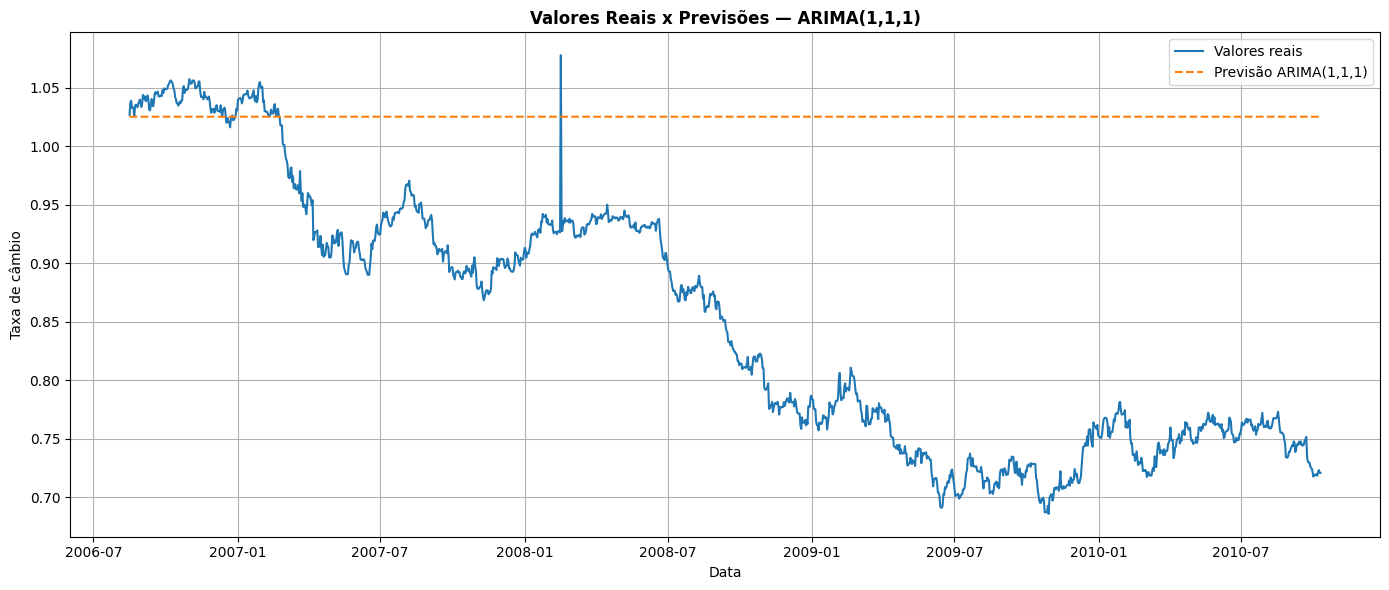

In [393]:
plt.figure(figsize=(14, 6))

plt.plot(
    teste.index,
    teste,
    label="Valores reais"
)

plt.plot(
    teste.index,
    previsao,
    label="Previsão ARIMA(1,1,1)",
    linestyle="--"
)

plt.title(
    "Valores Reais x Previsões — ARIMA(1,1,1)",
    fontweight="bold"
)

plt.xlabel("Data")
plt.ylabel("Taxa de câmbio")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

##**18.3 Resíduos**

In [394]:
residuos = resultado.resid

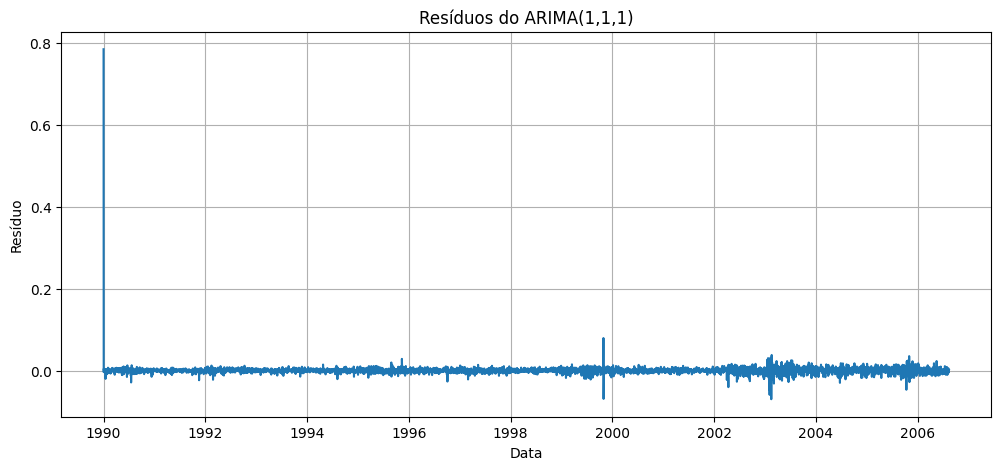

In [395]:
plt.figure(figsize=(12,5))
plt.plot(residuos)
plt.title("Resíduos do ARIMA(1,1,1)")
plt.xlabel("Data")
plt.ylabel("Resíduo")
plt.grid(True)
plt.show()

###**18.3.1 ACF dos Resíduos**

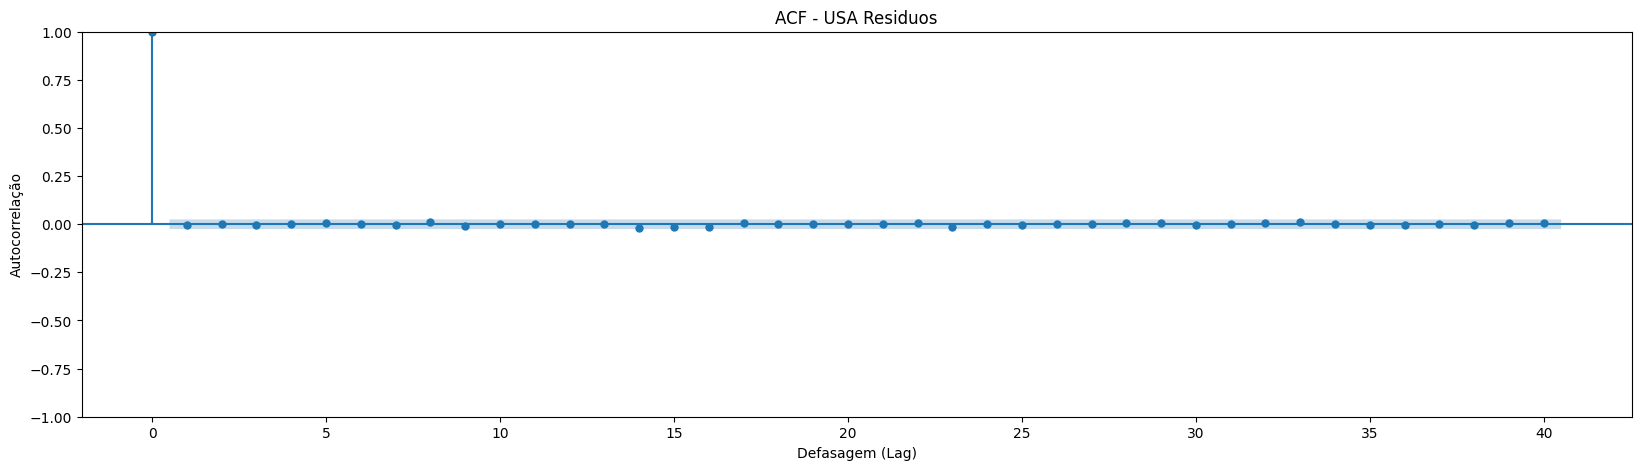

In [396]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

serie = residuos.dropna()

plt.figure(figsize=(20, 5))
plot_acf(serie, lags=40, ax=plt.gca())

plt.title("ACF - USA Residuos")
plt.xlabel("Defasagem (Lag)")
plt.ylabel("Autocorrelação")
plt.show()

A função de autocorrelação (ACF) dos resíduos do modelo ARIMA(1,1,1) foi analisada considerando 40 defasagens. Observa-se que, exceto pelo lag 0, cuja **autocorrelação é naturalmente igual a 1**, os **demais valores permanecem próximos de zero e dentro dos intervalos de confiança**. Esse **comportamento indica ausência de autocorrelação significativa nos resíduos**, sugerindo que o modelo conseguiu capturar **adequadamente a estrutura temporal presente na série**.

Dessa forma, os resíduos apresentam comportamento**compatível com um ruído branco**, sendo este um **indicativo favorável para a adequação do modelo**.

### **18.3.2 Teste de Ljung-Box**
Método estatístico usado para verificar se os erros (ou resíduos) de um modelo de séries temporais são aleatórios e independentes, comportando-se como um ruído branco

In [397]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung = acorr_ljungbox(
    residuos.dropna(),
    lags=[10, 20],
    return_df=True
)

print(ljung)

     lb_stat  lb_pvalue
10  1.648788   0.998392
20  5.916139   0.999006


## **18.4 Conclusão e Resultados**
Para avaliar se os resíduos do modelo ARIMA(1,1,1) apresentam autocorrelação, foi aplicado o teste de Ljung-Box considerando as defasagens 10 e 20. Os resultados apresentaram p-valores de 0,998392 e 0,999006, respectivamente.

Como ambos os p-valores são superiores ao nível de significância de 5%, não se rejeita a hipótese nula de ausência de autocorrelação dos resíduos. Dessa forma, não foram identificadas evidências estatísticas de dependência temporal remanescente nas defasagens avaliadas. Esse resultado, em conjunto com a análise da ACF dos resíduos, indica que não há evidências relevantes de autocorrelação residual, fornecendo suporte à adequação do modelo ARIMA(1,1,1).

Os resíduos não apresentam evidência de autocorrelação significativa pelo **teste de Ljung-Box**, indicando que o **modelo capturou adequadamente a dependência temporal analisada**. Entretanto, o **teste de Jarque-Bera rejeita a hipótese de normalidade dos resíduos, enquanto o teste de heterocedasticidade indica variância não constante**. Dessa forma, embora o **modelo apresente bom desempenho preditivo**, seus resíduos ainda apresentam **características que indicam limitações** no ajuste estatístico.